# ADSP 32018 IP01 Next-Gen NLP: Transformers, LLMs and AgenticAI in Practice - Final Project

## Part 4: Entity Extraction

**Objective of this Notebook:**

The purpose of this notebook is to extract two types of structured entities from the filtered news corpus: **organizations** and **technology-related terms**. To do this, I use a hybrid entity extraction pipeline that combines a pretrained transformer-based NER model with rule-based phrase matching. Specifically, I apply the Hugging Face **`dslim/distilbert-NER`** model to identify organization entities from article text, and I use **spaCy PhraseMatcher** with a curated technology lexicon to detect technology and AI-impact-related terms. The resulting outputs are then cleaned, standardized, and consolidated into a unified entity-level table that supports downstream analysis of how AI is discussed across industries, firms, and technologies.

**Plan:**

* Load the filtered document-level dataset produced in the earlier preprocessing steps and prepare the text field used for entity extraction.
* Split long documents into manageable overlapping chunks so that the transformer-based NER model can process text more reliably without losing positional information.
* Apply the pretrained **`dslim/distilbert-NER`** pipeline to extract **organization** entities, then filter results using confidence thresholds and basic validity rules.
* Build a **spaCy PhraseMatcher** using a curated list of AI, technology, and impact-related terms, and use it to extract **technology** entities from the same corpus.
* Normalize entity surface forms, remove noisy or invalid matches, and deduplicate repeated mentions while preserving document-level traceability.
* Combine organization entities and technology entities into a unified long-format table with row, date, source, and industry metadata.
* Generate descriptive summaries of entity frequency, document coverage, and industry-level distributions to validate extraction quality.
* Analyze co-occurrence patterns between organizations and technologies to identify which firms are most frequently discussed alongside specific AI-related concepts.
* Save the cleaned entity outputs for downstream sentiment analysis, industry impact analysis, and visualization.


## 0. Imports & Environment Setup

In this notebook, we combine general-purpose data processing libraries with two complementary entity extraction tools. `transformers` is used for model-based organization extraction, while `spaCy`'s `PhraseMatcher` is used for high-precision technology term matching.

This setup reflects the structure of the task: organizations are open-ended named entities that benefit from a pretrained NER model, whereas technology-impact terms are domain-defined phrases that can be matched more reliably with a curated dictionary.

In [1]:
import re

import pandas as pd
import numpy as np

import spacy
from spacy.matcher import PhraseMatcher

from tqdm.auto import tqdm

import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from transformers.pipelines.pt_utils import KeyDataset

import matplotlib.pyplot as plt

## 1. Load the Input Dataset

### 1.1 Read the BERTopic-Enriched Document Table

In this step, we load the document-level dataset produced in the earlier BERTopic and industry-assignment stages. This table serves as the starting point for entity extraction because it already contains the cleaned article text as well as downstream metadata such as `row_id`, `month`, `topic_id`, and `industry`.

By keeping entity extraction in the same document table, we make it easier to connect extracted entities back to the article-level analysis later in the pipeline.

In [2]:
df = pd.read_parquet("./data/bertopic/bertopic_assigned.parquet")
df.head()

,row_id,date,language,title,title_clean,text,text_clean_light,url,char_count,token_count,...,support_hits,relevance_score,year,month,model_text,topic_id,topic_confidence,is_top_10,is_top_20,industry
0,2199,2022-01-01,en,"Telecom giant KT to develop its own NPU, AI ec...","Telecom giant KT to develop its own NPU, AI ec...","Telecom giant KT to develop its own NPU, AI ec...","Telecom giant KT to develop its own NPU, AI ec...",https://www.newsbreak.com/news/2472208289685/t...,13117,1674,...,2,28,2022,2022-01,Telecom giant KT to develop its own NPU AI eco...,2,1.000000,True,True,Sales and Related
1,69671,2022-01-01,en,Garrison named one of ‘Washington’s Most Power...,Garrison named one of ‘Washington’s Most Power...,Garrison named one of ‘Washington’s Most Power...,Garrison named one of ‘Washington’s Most Power...,https://vestaviavoice.com/peopleplaces/garriso...,2222,348,...,0,26,2022,2022-01,Garrison named one of Washington s Most Powerf...,-1,0.000000,False,False,Other/Unclustered
2,94772,2022-01-01,en,Instapundit » Blog Archive » HMM: An Advan...,Instapundit » Blog Archive » HMM: An Advanced ...,Instapundit » Blog Archive » HMM: An Advan...,Instapundit » Blog Archive » HMM: An Advanced ...,https://pjmedia.com/instapundit/494418/,117,20,...,0,4,2022,2022-01,Instapundit Blog Archive HMM An Advanced AI Ga...,-1,0.000000,False,False,Other/Unclustered
3,96660,2022-01-01,en,5 Places to Start a Career in Data Science in ...,5 Places to Start a Career in Data Science in ...,5 Places to Start a Career in Data Science in ...,5 Places to Start a Career in Data Science in ...,https://www.newsbreak.com/news/2470570042311/5...,15628,2220,...,38,60,2022,2022-01,5 Places to Start a Career in Data Science in ...,2,0.971146,True,True,Sales and Related
4,117462,2022-01-01,en,Datametrex AI (CVE:DM) Trading Down 8% - Enter...,Datametrex AI (CVE:DM) Trading Down 8% - Enter...,Shares of Datametrex AI Limited (CVE:DM) fell ...,Shares of Datametrex AI Limited (CVE:DM) fell ...,https://theenterpriseleader.com/2022/01/01/dat...,1147,171,...,0,18,2022,2022-01,Shares of Datametrex AI Limited CVE DM fell 8 ...,-1,0.000000,False,False,Other/Unclustered


### 1.2 Inspect the Raw Columns

Before creating the working table, we first inspect the available columns in the BERTopic-enriched dataset. This helps verify that the text field, topic assignments, and industry labels needed for entity extraction are all present.

Doing this inspection early also makes the later merge and aggregation steps easier to follow.

In [3]:
df.columns

Index(['row_id', 'date', 'language', 'title', 'title_clean', 'text',
       'text_clean_light', 'url', 'char_count', 'token_count', 'alpha_ratio',
       'high_signal_hits', 'support_hits', 'relevance_score', 'year', 'month',
       'model_text', 'topic_id', 'topic_confidence', 'is_top_10', 'is_top_20',
       'industry'],
      dtype='str')

### 1.3 Create a Working Copy for Entity Extraction

Before extracting entities, we check the available columns and create a dedicated working dataframe for this notebook. We also select the primary text field that will be used for extraction so the rest of the pipeline can reference one consistent text column.

This small setup step helps avoid accidental modification of the original dataframe and keeps the extraction pipeline reproducible.


In [4]:
entity_extract_df = df.copy()
TEXT_COL = "text_clean_light"

## 2. Organization Entity Extraction with a Pretrained NER Model

### 2.1 Define Extraction Parameters and Normalize the Input Text

In this section, we configure the main hyperparameters for model-based entity extraction, including the pretrained checkpoint, chunk size, overlap, batch size, and score threshold. We also normalize the document text by removing repeated whitespace and converting missing values to empty strings so the downstream steps can run robustly.

These parameters control the tradeoff between runtime, coverage, and precision. In particular, chunking is necessary because long news articles can exceed the model context window.


In [5]:
MODEL_NAME = "dslim/distilbert-NER"

CHUNK_SIZE = 2000
OVERLAP = 120
BATCH_SIZE = 64
SCORE_THRESHOLD = 0.85

entity_extract_df = df.copy()

entity_extract_df[TEXT_COL] = (
    entity_extract_df[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

texts = entity_extract_df[TEXT_COL].tolist()

### 2.2 Load the DistilBERT NER Pipeline

Here, we initialize the tokenizer, model, and Hugging Face NER pipeline using `dslim/distilbert-NER`. We use `aggregation_strategy="first"` so subword-level predictions are merged into cleaner entity spans, and we automatically choose GPU when available to speed up inference.

This model-based step is primarily used to identify organization mentions, which are more varied and open-ended than the technology phrases handled later with rule-based matching.


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)

device = 0 if torch.cuda.is_available() else -1

ner_pipe = pipeline(
    task="ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="first",
    device=device
)

print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Using device: GPU


### 2.3 Segment Long Documents into Overlapping Chunks

Because many documents are longer than a single model pass can safely handle, we split each article into overlapping character-based segments. The overlap helps reduce boundary errors, where an entity might otherwise be split across two adjacent chunks.

The output of this function is not yet the final entity table. Instead, it creates chunk-level units that preserve the original character offsets, which will later let us map extracted entities back to document-level spans.


In [7]:
def segment_text_by_chars(text: str, chunk_size: int = 600, overlap: int = 120):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"\s+", " ", text).strip()

    if not text:
        return []

    segments = []
    start = 0
    n = len(text)

    while start < n:
        end = min(start + chunk_size, n)
        segments.append({
            "chunk_text": text[start:end],
            "chunk_start": start,
            "chunk_end": end
        })

        if end == n:
            break

        start = end - overlap

    return segments

### 2.4 Build the Chunk-Level Inference Table

In this step, we apply the segmentation function to every document and create a chunk-level dataframe. Each row represents one document segment and stores the originating `row_id`, segment id, text, and start/end offsets.

This chunk table is the main input to the NER inference stage and acts as a bridge between full-document text and model-sized inputs.

In [8]:
chunk_rows = []

for row_id, text in enumerate(tqdm(texts, desc="Segmenting documents")):
    segments = segment_text_by_chars(
        text=text,
        chunk_size=CHUNK_SIZE,
        overlap=OVERLAP
    )
    for seg_id, seg in enumerate(segments):
        chunk_rows.append({
            "row_id": row_id,
            "seg_id": seg_id,
            "chunk_text": seg["chunk_text"],
            "chunk_start": seg["chunk_start"],
            "chunk_end": seg["chunk_end"]
        })

chunks_df = pd.DataFrame(chunk_rows)

print(f"Total documents: {len(entity_extract_df):,}")
print(f"Total chunks: {len(chunks_df):,}")
display(chunks_df.head())

Segmenting documents:   0%|          | 0/174826 [00:00<?, ?it/s]

Total documents: 174,826
Total chunks: 523,673


,row_id,seg_id,chunk_text,chunk_start,chunk_end
0,0,0,"Telecom giant KT to develop its own NPU, AI ec...",0,2000
1,0,1,vacy PolicyDo Not Sell My InfoHelp CenterAbout...,1880,3880
2,0,2,conomic Daily#Intel Corp#Ibm#Xilinx#Advanced M...,3760,5760
3,0,3,earlier this month after the U.S. government a...,5640,7640
4,0,4,that's had been facing off a flurry of sancti...,7520,9520


### 2.5 Run NER Inference on All Chunks

Once the chunk table is prepared, we convert it into a Hugging Face `Dataset` and run batched NER inference across all segments. The resulting predictions are stored at the chunk level so we can inspect raw model outputs before any post-processing or document-level aggregation.

At this stage, the extracted entities are still relatively raw. The next steps clean, filter, and merge them into document-level organization mentions.

In [ ]:
chunk_dataset = Dataset.from_pandas(
    chunks_df[["chunk_text"]],
    preserve_index=False
)

all_chunk_results = list(
    tqdm(
        ner_pipe(KeyDataset(chunk_dataset, "chunk_text"), batch_size=BATCH_SIZE),
        total=len(chunk_dataset),
        desc="Running NER"
    )
)

chunks_df["ner_result"] = all_chunk_results
display(chunks_df[["row_id", "seg_id", "chunk_text", "ner_result"]].head())

,row_id,seg_id,chunk_text,ner_result
0,0,0,"Telecom giant KT to develop its own NPU, AI ec...","[{'end': 16, 'entity_group': 'ORG', 'score': 0..."
1,0,1,vacy PolicyDo Not Sell My InfoHelp CenterAbout...,"[{'end': 47, 'entity_group': 'ORG', 'score': 0..."
2,0,2,conomic Daily#Intel Corp#Ibm#Xilinx#Advanced M...,"[{'end': 24, 'entity_group': 'ORG', 'score': 0..."
3,0,3,earlier this month after the U.S. government a...,"[{'end': 30, 'entity_group': 'LOC', 'score': 0..."
4,0,4,that's had been facing off a flurry of sancti...,"[{'end': 70, 'entity_group': 'LOC', 'score': 0..."


### 2.6 Clean and Filter Raw Organization Predictions

The NER model may produce noisy or low-information outputs, so this section defines a set of helper functions for post-processing. We standardize entity text, remove invalid fragments, and convert chunk-relative offsets into document-level spans.

This is an important precision-control step: instead of using every raw model prediction directly, we keep only organization candidates that meet basic textual quality checks and score thresholds.

In [10]:
def clean_entity_text(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

def is_valid_org_text(text: str) -> bool:
    text = clean_entity_text(text)
    if len(text) <= 1:
        return False
    if not re.search(r"[A-Za-z]", text):
        return False
    if text.lower() in {"the", "a", "an"}:
        return False
    return True

def extract_orgs_from_chunk_result(ner_result, chunk_start, score_threshold=0.85):
    """
    Convert one chunk's NER output to document-level ORG records.
    Output: list of dicts
    """
    out = []

    if not isinstance(ner_result, list):
        return out

    for ent in ner_result:
        label = ent.get("entity_group", ent.get("entity", ""))
        score = float(ent.get("score", 0.0))
        entity_text = clean_entity_text(ent.get("word", ""))


        if label == "ORG" and score >= score_threshold and is_valid_org_text(entity_text):

            out.append({
                "entity_text": entity_text,
                "start": int(ent["start"]) + int(chunk_start),
                "end": int(ent["end"]) + int(chunk_start),
                "entity_type": "ORG",
                "score": score,
                "source": "distilbert_ner_segmented_first"
            })

    return out

### 2.7 Apply the Organization Extraction Logic to Each Chunk

Here, we run the extraction helper on every chunk and store the resulting organization records. Each record contains the entity text, span information, confidence score, and entity type, making it easier to merge chunk-level predictions later.

The output is still organized by chunk, but the entity spans are now aligned to the original document coordinates.

In [11]:
SCORE_THRESHOLD = 0.75

chunks_df["org_records"] = chunks_df.apply(
    lambda row: extract_orgs_from_chunk_result(
        ner_result=row["ner_result"].tolist(),
        chunk_start=row["chunk_start"],
        score_threshold=SCORE_THRESHOLD
    ),
    axis=1
)

display(chunks_df[["row_id", "seg_id", "org_records"]].head())

,row_id,seg_id,org_records
0,0,0,[{'entity_text': '. PoliticsMilitaryCongress &...
1,0,1,"[{'entity_text': 'EconomyTelecom', 'start': 19..."
2,0,2,"[{'entity_text': 'CNET', 'start': 4898, 'end':..."
3,0,3,"[{'entity_text': 'SenseTime', 'start': 5691, '..."
4,0,4,"[{'entity_text': 'Telefonica SA', 'start': 766..."


### 2.8 Deduplicate and Aggregate Organizations at the Document Level

Because chunk overlap can cause the same organization mention to be detected multiple times, we explicitly deduplicate organization records after inference. We then aggregate the cleaned records back to the document level and store a compact representation in `entity_extract_df`.

This produces the main organization-entity fields that will later be combined with technology entities in a shared long-format table.

In [12]:
def deduplicate_org_records(records):
    seen = set()
    deduped = []

    for rec in records:
        key = (
            rec["entity_text"].strip().lower(),
            int(rec["start"]),
            int(rec["end"])
        )
        if key not in seen:
            seen.add(key)
            deduped.append(rec)

    deduped = sorted(deduped, key=lambda x: (x["start"], x["end"], x["entity_text"].lower()))
    return deduped

In [13]:
doc_org_map = {}

for _, row in chunks_df.iterrows():
    row_id = int(row["row_id"])
    recs = row["org_records"] if isinstance(row["org_records"], list) else []

    if row_id not in doc_org_map:
        doc_org_map[row_id] = []

    doc_org_map[row_id].extend(recs)

doc_level_org_entities = []
doc_level_org_spans = []

for row_id in range(len(entity_extract_df)):
    recs = doc_org_map.get(row_id, [])
    recs = deduplicate_org_records(recs)

    doc_level_org_entities.append([r["entity_text"] for r in recs])
    doc_level_org_spans.append([(r["start"], r["end"]) for r in recs])

entity_extract_df["org_entity"] = doc_level_org_entities
entity_extract_df["org_entity_spans"] = doc_level_org_spans

## 3. Technology Entity Extraction with Rule-Based Phrase Matching

### 3.1 Define a Domain-Specific Technology Vocabulary

Not all entities in this project are best handled with a pretrained NER model. For technology-impact concepts such as automation, augmentation, workflow redesign, and cost reduction, a curated dictionary is often more precise and more interpretable.

In this section, we create a `PhraseMatcher` and define a domain-specific list of technology terms that represent common ways AI may affect an industry or organization.

In [14]:
TEXT_COL = "model_text"

nlp_sm = spacy.blank("en")
tech_matcher = PhraseMatcher(nlp_sm.vocab, attr="LOWER")

TECH_TERMS = [
    "task automation",
    "process automation",
    "intelligent automation",
    "robotic process automation",
    "end-to-end automation",
    "autonomous systems",
    "human-in-the-loop automation",
    "labor substitution",

    "human-AI augmentation",
    "decision augmentation",
    "cognitive augmentation",
    "AI copilots",
    "assistive AI",
    "augmented decision-making",
    "productivity enhancement",

    "workflow redesign",
    "process re-engineering",
    "AI-native workflows",
    "pipeline optimization",
    "operational transformation",
    "intelligent orchestration",
    "end-to-end workflow optimization",

    "cost reduction",
    "operational efficiency",
    "margin improvement",
    "scalability improvements",
    "resource optimization",
    "productivity gains",
    "throughput optimization",

    "predictive analytics",
    "decision intelligence",
    "real-time analytics",
    "optimization engines",
    "forecasting accuracy improvements",
    "risk scoring",
    "decision automation",

    "personalization at scale",
    "intelligent recommendation",
    "adaptive systems",
    "dynamic content generation",
    "conversational interfaces",
    "context-aware systems",
    "customer experience optimization",

    "risk mitigation",
    "error reduction",
    "compliance monitoring",
    "model governance",
    "explainable AI",
    "bias detection",
    "auditability",

    "workforce transformation",
    "job displacement",
    "skill shift",
    "reskilling and upskilling",
    "role redefinition",
    "organizational redesign",

    "product innovation",
    "AI-enabled products",
    "new business models",
    "service innovation",
    "time-to-market reduction",
    "continuous improvement loops",

    "uncertain impact",
    "mixed outcomes",
    "uneven adoption",
    "partial automation",
    "adoption barriers"
]

tech_matcher.add("TECH", [nlp_sm.make_doc(t) for t in TECH_TERMS])


def deduplicate_mentions(texts, spans):
    """
    Remove exact duplicate matches with the same text and span.
    Keep repeated mentions if they appear at different positions.
    """
    seen = set()
    dedup_texts = []
    dedup_spans = []

    for text, span in zip(texts, spans):
        key = (str(text).strip().lower(), int(span[0]), int(span[1]))
        if key not in seen:
            seen.add(key)
            dedup_texts.append(text)
            dedup_spans.append(span)

    return dedup_texts, dedup_spans


def extract_tech_lists(text: str):
    """
    Return:
    - tech_entity: list[str]
    - tech_entity_span: list[tuple[int, int]]
    """
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"\s+", " ", text).strip()

    if not text:
        return {
            "tech_entity": [],
            "tech_entity_span": []
        }

    doc = nlp_sm(text)
    matches = tech_matcher(doc)

    tech_entity = []
    tech_entity_span = []

    for _, start, end in matches:
        span = doc[start:end]
        tech_entity.append(span.text)
        tech_entity_span.append((int(span.start_char), int(span.end_char)))

    tech_entity, tech_entity_span = deduplicate_mentions(tech_entity, tech_entity_span)

    return {
        "tech_entity": tech_entity,
        "tech_entity_span": tech_entity_span
    }

### 3.2 Extract Technology Entities and Their Spans

Using the phrase matcher, we scan each document for technology-related expressions and store both the matched text and the corresponding character spans. Compared with open-ended NER, this rule-based approach gives us strong control over the semantic categories we want to study.

The result is a document-level list of technology mentions that is directly comparable across industries and time periods.


In [15]:
entity_extract_df["tech_entity"] = entity_extract_df[TEXT_COL].apply(
    lambda text: extract_tech_lists(text)["tech_entity"]
)

entity_extract_df["tech_entity_span"] = entity_extract_df[TEXT_COL].apply(
    lambda text: extract_tech_lists(text)["tech_entity_span"]
)

display(entity_extract_df[[TEXT_COL, "tech_entity", "tech_entity_span"]].head())

,model_text,tech_entity,tech_entity_span
0,Telecom giant KT to develop its own NPU AI eco...,[],[]
1,Garrison named one of Washington s Most Powerf...,[],[]
2,Instapundit Blog Archive HMM An Advanced AI Ga...,[],[]
3,5 Places to Start a Career in Data Science in ...,[],[]
4,Shares of Datametrex AI Limited CVE DM fell 8 ...,[],[]


### 3.3 Perform a Lightweight Coverage Check

After extraction, we compute a simple coverage statistic: how many documents contain at least one technology entity. This sanity check helps confirm that the vocabulary is broad enough to capture relevant AI-impact language without being too sparse.


In [ ]:
num_with_tech = entity_extract_df["tech_entity"].apply(lambda x: len(x) > 0).sum()
total_rows = len(entity_extract_df)
print(f"Number of rows with at least one tech_entity: {num_with_tech:,} / {total_rows:,} ({num_with_tech/total_rows:.2%})")

Number of rows with at least one tech_entity: 12,382 / 174,826 (7.08%)


## 4. Build a Unified Long-Format Entity Table

### 4.1 Convert Document-Level Organization Lists into Rows

For downstream analysis, it is more convenient to represent entities in long format, with one row per entity mention rather than one list per document. This section explodes the document-level organization lists into a row-level table and preserves the mention spans and normalized text.

A long-format structure makes grouping, filtering, deduplication, and aggregation much easier later on.


In [17]:
org_rows = []

for _, row in entity_extract_df.iterrows():
    row_id = row["row_id"]

    org_entities = row["org_entity"] if isinstance(row["org_entity"], list) else []
    org_spans = row["org_entity_spans"] if isinstance(row["org_entity_spans"], list) else []

    for i, (entity_text, span) in enumerate(zip(org_entities, org_spans)):
        start, end = span

        org_rows.append({
            "row_id": row_id,
            "entity_text": entity_text,
            "start": int(start),
            "end": int(end),
            "entity_type": "ORG",
            "source": "distilbert_ner_segmented_first"
        })

org_entities_df = pd.DataFrame(org_rows)

display(org_entities_df.head())
print(org_entities_df.shape)

,row_id,entity_text,start,end,entity_type,source
0,2199,. PoliticsMilitaryCongress & CourtsElectionsLa...,337,396,ORG,distilbert_ner_segmented_first
1,2199,EconomyTelecom,1948,1962,ORG,distilbert_ner_segmented_first
2,2199,KT,1969,1971,ORG,distilbert_ner_segmented_first
3,2199,KT Corp.,2142,2150,ORG,distilbert_ner_segmented_first
4,2199,Microsoft,2678,2687,ORG,distilbert_ner_segmented_first


(2685784, 6)


### 4.2 Convert Document-Level Technology Lists into Rows

We repeat the same reshaping step for the technology entities. Each matched technology mention becomes its own row with document id, span, raw text, normalized text, and entity type.

By processing organizations and technologies in parallel, we make the final tables consistent and easier to concatenate.


In [18]:
tech_rows = []

for _, row in entity_extract_df.iterrows():
    row_id = row["row_id"]

    tech_entities = row["tech_entity"] if isinstance(row["tech_entity"], list) else []
    tech_spans = row["tech_entity_span"] if isinstance(row["tech_entity_span"], list) else []

    for entity_text, span in zip(tech_entities, tech_spans):
        start, end = span

        tech_rows.append({
            "row_id": row_id,
            "entity_text": entity_text,
            "start": int(start),
            "end": int(end),
            "entity_type": "TECH",
            "source": "lexicon"
        })

tech_entities_df = pd.DataFrame(tech_rows)

display(tech_entities_df.head())
print(tech_entities_df.shape)

,row_id,entity_text,start,end,entity_type,source
0,17228,intelligent automation,2406,2428,TECH,lexicon
1,17228,Robotic Process Automation,2962,2988,TECH,lexicon
2,17228,Process Automation,2970,2988,TECH,lexicon
3,54868,intelligent automation,3347,3369,TECH,lexicon
4,54868,Robotic Process Automation,3863,3889,TECH,lexicon


(19342, 6)


### 4.3 Combine All Entity Mentions into a Single Table

In this step, we concatenate the organization and technology tables into one unified entity dataset called `doc_entities`. This becomes the central output of the notebook because it provides a shared schema for all extracted mentions regardless of entity type.

Once this table is built, we can move from extraction to descriptive analysis.

In [38]:
doc_entities = pd.concat(
    [org_entities_df, tech_entities_df],
    axis=0,
    ignore_index=True
)

doc_entities = doc_entities.sort_values(
    ["row_id", "start", "end", "entity_type", "entity_text"],
    ascending=[True, True, True, True, True]
).reset_index(drop=True)

display(doc_entities.head(20))
print(doc_entities.shape)

,row_id,entity_text,start,end,entity_type,source
0,0,BlockworksOpen,67,81,ORG,distilbert_ner_segmented_first
1,0,KMNO,2202,2206,ORG,distilbert_ner_segmented_first
2,0,ResearchSolana Meta AggregatorsMeta,2325,2360,ORG,distilbert_ner_segmented_first
3,0,Titan,2378,2383,ORG,distilbert_ner_segmented_first
4,0,Kamino Swap,2388,2399,ORG,distilbert_ner_segmented_first
5,0,Jupiter,2490,2497,ORG,distilbert_ner_segmented_first
6,1,AI Art,370,376,ORG,distilbert_ner_segmented_first
7,2,ChatGPT,137,144,ORG,distilbert_ner_segmented_first
8,2,GoogleAI,848,856,ORG,distilbert_ner_segmented_first
9,2,MetaAI,1407,1413,ORG,distilbert_ner_segmented_first


(2705126, 6)


In [ ]:
entity_extract_df.to_parquet("./data/entity/entity_extract.parquet", index=False, engine="pyarrow")
doc_entities.to_parquet("./data/entity/doc_entities.parquet", index=False, engine="pyarrow")

## 5. Exploratory Analysis of Extracted Entities

### 5.1 Identify the Most Frequent Organizations and Technologies

With the unified entity table in place, we first compute simple global frequency summaries. We count how many distinct documents mention each organization or technology term and rank the most common entities.

These summaries provide a first view of what kinds of actors and impact mechanisms appear most often in the corpus.

In [21]:
org_global = (
    doc_entities.query("entity_type == 'ORG'")
    .groupby("entity_text", as_index=False)
    .agg(doc_freq=("row_id","nunique"))
    .sort_values("doc_freq", ascending=False)
    .head(30)
)

tech_global = (
    doc_entities.query("entity_type == 'TECH'")
    .groupby("entity_text", as_index=False)
    .agg(doc_freq=("row_id","nunique"))
    .sort_values("doc_freq", ascending=False)
    .head(30)
)

### 5.2 Visualize Global Entity Frequency Patterns

To make the frequency results easier to interpret, we plot the top organization and technology entities side by side. This gives a quick visual sense of which names and concepts dominate the document collection before moving into industry-level analysis.


In [22]:
tech_global

,entity_text,doc_freq
90,operational efficiency,1678
97,predictive analytics,1229
101,productivity gains,652
98,process automation,557
85,job displacement,440
67,autonomous systems,431
82,intelligent automation,421
99,product innovation,272
104,risk mitigation,220
72,cost reduction,209


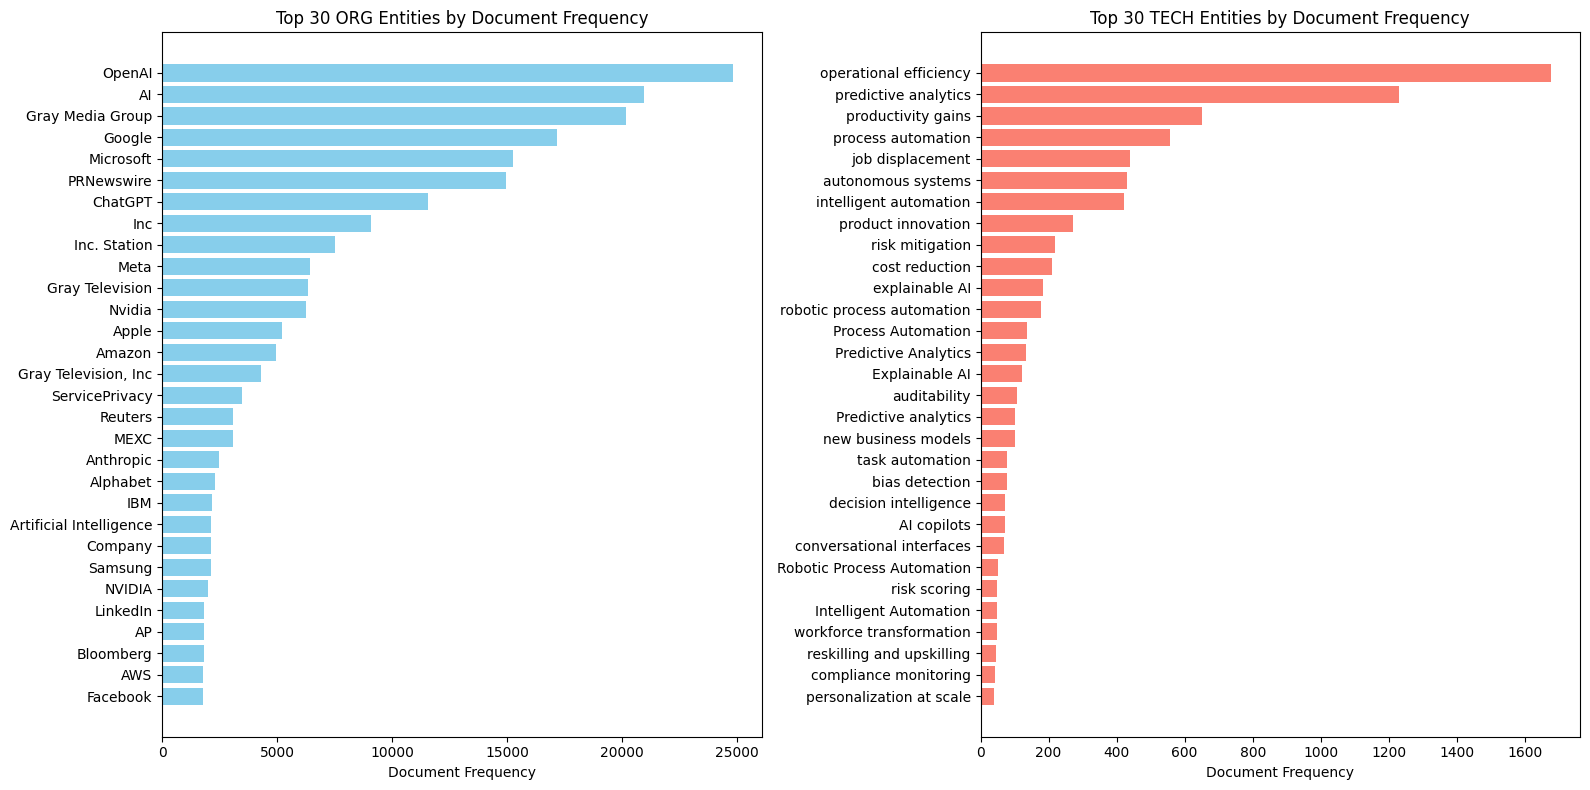

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(org_global["entity_text"], org_global["doc_freq"], color="skyblue")
axes[0].set_title("Top 30 ORG Entities by Document Frequency")
axes[0].set_xlabel("Document Frequency")
axes[0].invert_yaxis()

axes[1].barh(tech_global["entity_text"], tech_global["doc_freq"], color="salmon")
axes[1].set_title("Top 30 TECH Entities by Document Frequency")
axes[1].set_xlabel("Document Frequency")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Aggregate Entities by Time, Industry, and Topic

### 6.1 Merge Entity Mentions Back with Document Metadata

Entity extraction becomes much more useful once each mention is linked back to the document metadata produced earlier in the project. In this step, we merge `doc_entities` with the main document table and aggregate counts by month, industry, topic, entity type, and entity text.

This creates an analysis-ready table for studying how entity mentions vary across industries and over time.


In [24]:
doc_entities = doc_entities.merge(
    entity_extract_df,
    on="row_id",
    how="left"
)

entity_agg = (
    doc_entities
    .groupby(["month", "industry", "topic_id", "entity_type", "entity_text"], as_index=False)
    .agg(
        doc_freq=("row_id", "nunique"),
        mention_count=("entity_text", "size")
    )
    .sort_values(["month", "doc_freq"], ascending=[True, False])
)

entity_agg.head(20)

,month,industry,topic_id,entity_type,entity_text,doc_freq,mention_count
2027,2022-01,Other/Unclustered,-1,ORG,Gray Media Group,120,180
958,2022-01,Healthcare Support,0,ORG,Gray Media Group,117,178
2489,2022-01,Other/Unclustered,-1,ORG,PRNewswire,81,87
2103,2022-01,Other/Unclustered,-1,ORG,Inc,74,86
1151,2022-01,Healthcare Support,0,ORG,PRNewswire,64,67
2028,2022-01,Other/Unclustered,-1,ORG,Gray Television,64,64
1507,2022-01,Other/Unclustered,-1,ORG,AI,45,59
988,2022-01,Healthcare Support,0,ORG,Inc,43,50
2323,2022-01,Other/Unclustered,-1,ORG,Meta,43,123
2130,2022-01,Other/Unclustered,-1,ORG,Inc. Station,38,38


### 6.2 Find the Most Frequent Organizations within Each Industry

Using the aggregated entity table, we rank organizations by document frequency within each industry. This helps answer which companies, institutions, or other named organizations are most strongly associated with each industry-specific AI discussion.

In [25]:
top_org_by_industry = (
    entity_agg.query("entity_type=='ORG'")
    .groupby(["industry", "entity_text"], as_index=False)["doc_freq"].sum()
    .sort_values(["industry", "doc_freq"], ascending=[True, False])
)

top_org_by_industry.groupby("industry").head(10)

,industry,entity_text,doc_freq
6245,"Arts, Design, Entertainment, Sports, and Media",OpenAI,789
192,"Arts, Design, Entertainment, Sports, and Media",AI,706
4909,"Arts, Design, Entertainment, Sports, and Media",Ltd,684
3571,"Arts, Design, Entertainment, Sports, and Media",Google,505
3810,"Arts, Design, Entertainment, Sports, and Media",HeyGen,301
...,...,...,...
261299,Sales and Related,Benzinga,547
274424,Sales and Related,Nvidia,529
272485,Sales and Related,Meta,486
260095,Sales and Related,Apple,481


### 6.3 Visualize Top Organizations by Industry

These plots break the organization frequencies out by industry so we can compare which entities dominate different parts of the taxonomy. Because many organization names are long, the plotting code also includes label truncation and layout adjustments for readability.


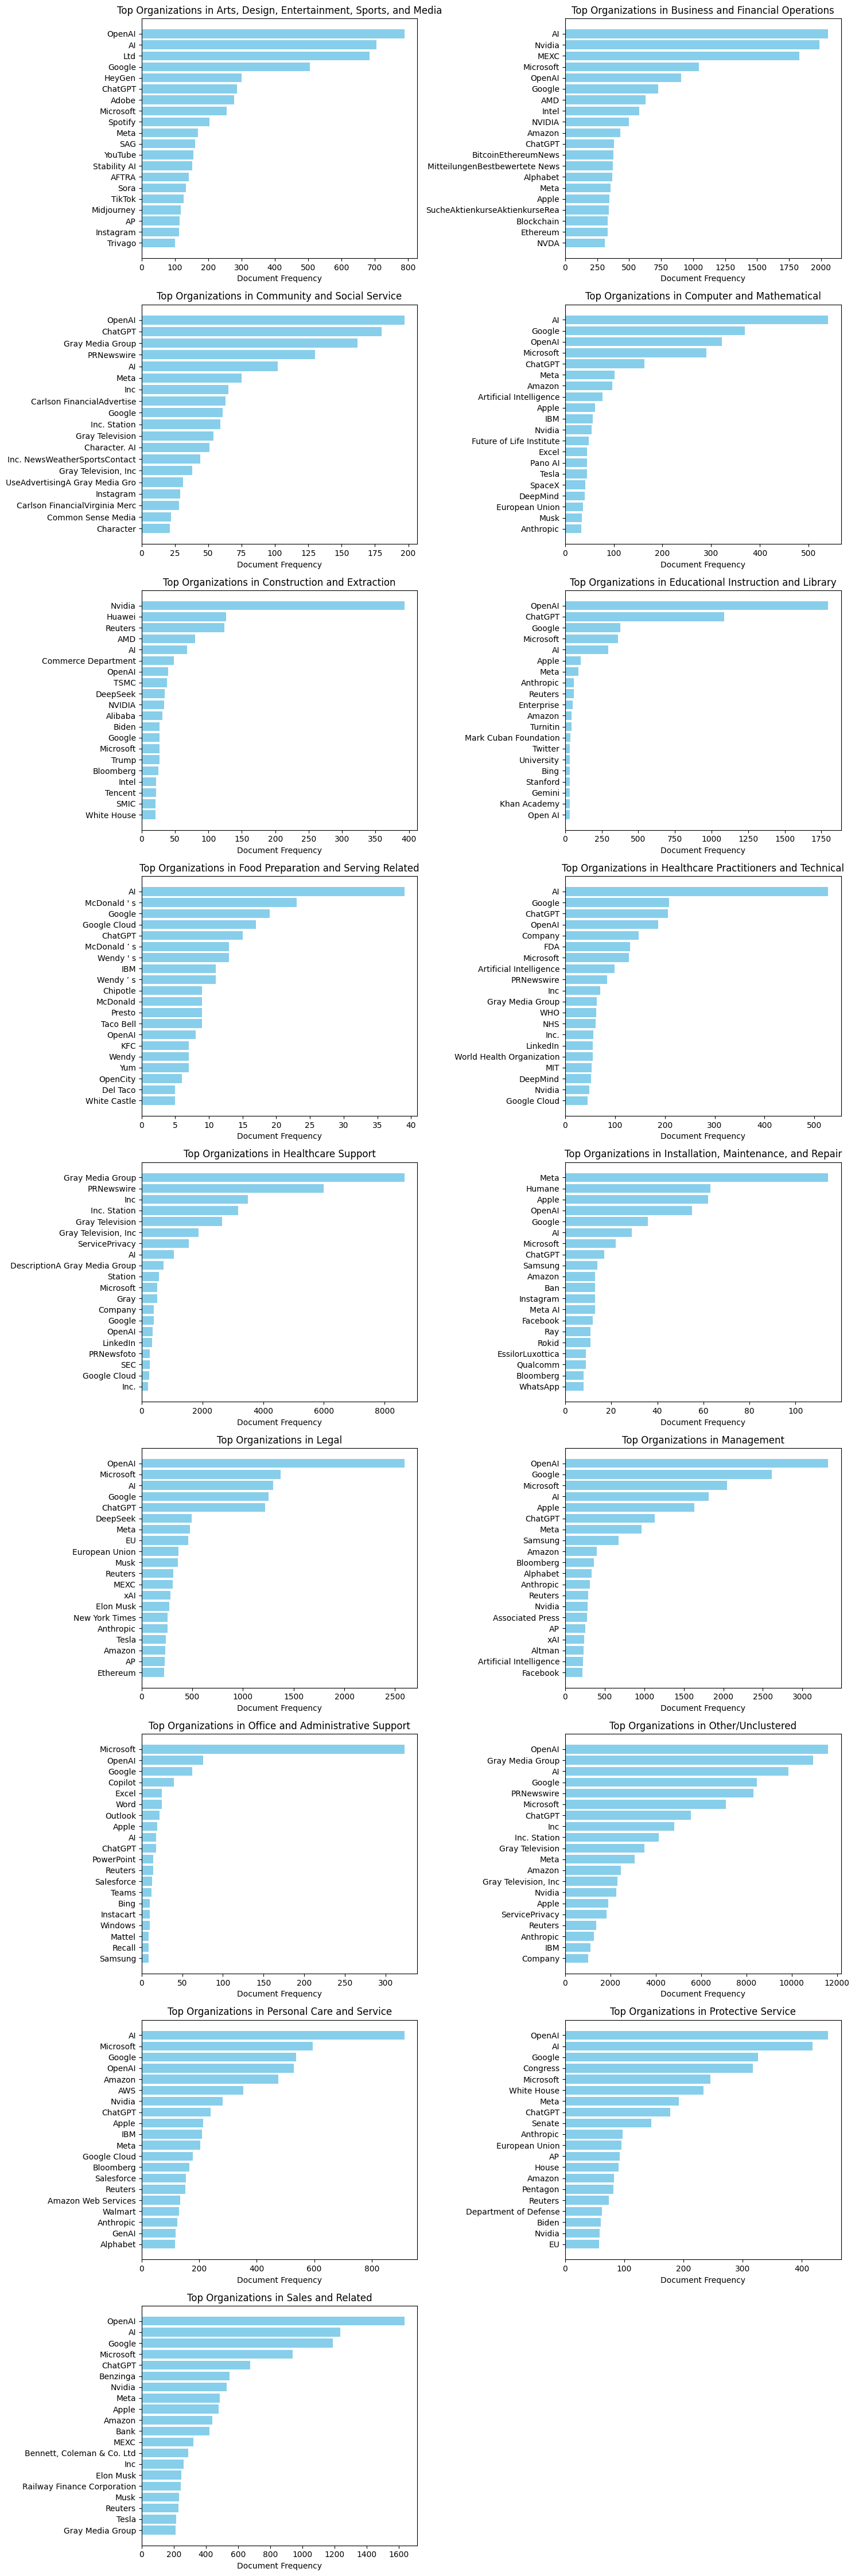

In [ ]:
industries = top_org_by_industry["industry"].unique()
num_industries = len(industries)
num_cols = 2
num_rows = (num_industries + num_cols - 1) // num_cols
plt.figure(figsize=(15, num_rows * 5))
for i, industry in enumerate(industries):
    plt.subplot(num_rows, num_cols, i + 1)
    data = top_org_by_industry[top_org_by_industry["industry"] == industry].head(20)
    plt.barh(data["entity_text"].str.slice(0, 30), data["doc_freq"], color="skyblue")
    plt.xlabel("Document Frequency")
    plt.title(f"Top Organizations in {industry}")
    plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 6.4 Find the Most Frequent Technologies within Each Industry

We now repeat the same logic for technology entities. Instead of asking which organizations are most common, we ask which AI-impact mechanisms and technology concepts appear most often in each industry.

This is especially important for the project objective, since the technology terms help characterize how AI is expected to affect each domain.

In [27]:
top_tech_by_industry = (
    entity_agg.query("entity_type=='TECH'")
    .groupby(["industry", "entity_text"], as_index=False)["doc_freq"].sum()
    .sort_values(["industry", "doc_freq"], ascending=[True, False])
)
top_tech_by_industry.groupby("industry").head(10)

,industry,entity_text,doc_freq
16,"Arts, Design, Entertainment, Sports, and Media",job displacement,16
18,"Arts, Design, Entertainment, Sports, and Media",operational efficiency,13
13,"Arts, Design, Entertainment, Sports, and Media",cost reduction,7
21,"Arts, Design, Entertainment, Sports, and Media",productivity gains,6
0,"Arts, Design, Entertainment, Sports, and Media",Assistive AI,4
...,...,...,...
579,Sales and Related,intelligent automation,24
587,Sales and Related,process automation,19
588,Sales and Related,product innovation,17
562,Sales and Related,Process Automation,16


### 6.5 Visualize Top Technologies by Industry

The industry-level technology plots provide a compact comparison of the dominant AI-impact themes across the taxonomy. Together with the organization plots above, they help connect “who is being discussed” with “how AI is affecting them.”

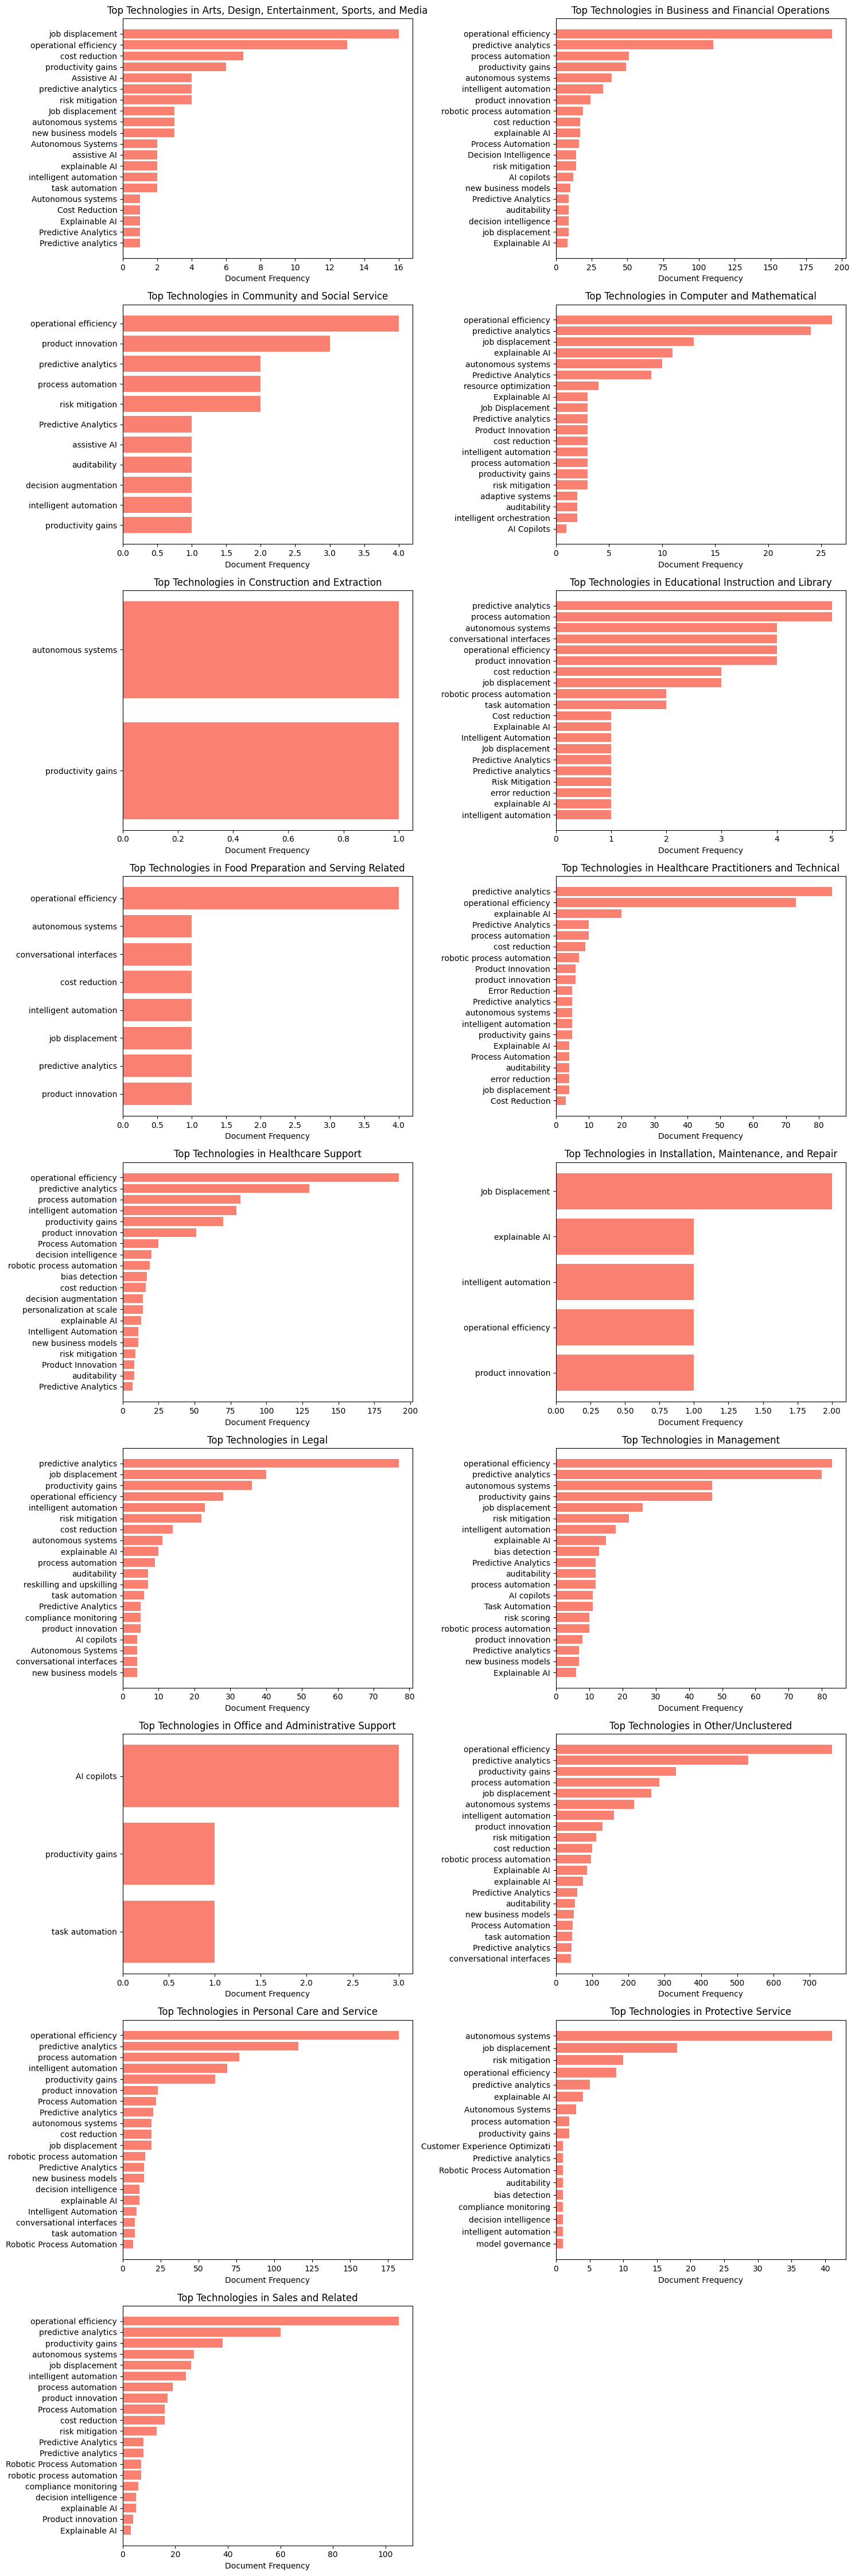

In [ ]:
industries = top_tech_by_industry["industry"].unique()
num_industries = len(industries)
num_cols = 2
num_rows = (num_industries + num_cols - 1) // num_cols
plt.figure(figsize=(15, num_rows * 5))
for i, industry in enumerate(industries):
    plt.subplot(num_rows, num_cols, i + 1)
    data = top_tech_by_industry[top_tech_by_industry["industry"] == industry].head(20)
    plt.barh(data["entity_text"].str.slice(0, 30), data["doc_freq"], color="salmon")
    plt.xlabel("Document Frequency")
    plt.title(f"Top Technologies in {industry}")
    plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()